# M. Alfatih_F1D02410013_Kelompok 1

# import library

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Blok kode di atas mengimpor tiga pustaka esensial untuk pemrosesan citra digital. numpy (np) digunakan untuk manipulasi array dan matriks mengingat citra beroperasi pada tingkat piksel. matplotlib.pyplot (plt) berfungsi untuk memvisualisasikan gambar sebelum dan sesudah diproses, sedangkan cv2 (OpenCV) adalah pustaka utama yang mengeksekusi seluruh operasi pengolahan citra seperti membaca file, mengubah ukuran, hingga menerapkan operasi morfologi.

# Deklarasi Fungsi - fungsi yang akan digunakan

In [9]:
def fungsi_satu(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if (img[i, j] > batas):
                canvas[i, j] = 255
            elif (img[i, j] <= batas):
                canvas[i, j] = 0
    return canvas

Blok kode di atas mendefinisikan sebuah fungsi kustom untuk melakukan thresholding biner secara manual tanpa menggunakan fungsi bawaan OpenCV. Fungsi bekerja dengan melakukan iterasi memindai setiap piksel pada citra untuk membandingkan nilai intensitasnya terhadap nilai ambang (batas). Jika intensitas piksel lebih besar dari ambang batas, nilainya akan diubah menjadi putih (255), sedangkan jika lebih kecil atau sama dengan batas akan diubah menjadi hitam (0), sehingga secara efektif menghasilkan citra biner baru.

In [10]:
def fungsi_dua(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

Blok kode  di atas mendefinisikan sebuah fungsi kustom untuk mengubah ukuran citra (resize) secara manual. Fungsi bekerja dengan membuat kanvas kosong berdimensi baru, lalu memetakan ulang setiap piksel dari citra asli ke citra baru menggunakan perhitungan rasio skala. Secara teknis, metode ini menerapkan algoritma interpolasi nearest-neighbor (ketetanggaan terdekat) dengan cara memotong nilai desimal koordinat menjadi bilangan bulat (int) untuk mengambil dan memindahkan nilai intensitas piksel asli yang letaknya paling bersesuaian.

In [11]:
def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
    return hasil

Blok kode di atas mendefinisikan implementasi manual dari operasi morfologi dilasi. Algoritma ini bekerja dengan melakukan iterasi pada citra biner; jika ditemukan piksel objek atau latar depan (bernilai putih atau 255), fungsi akan mencetak pola matriks kernel pada titik koordinat tersebut. Proses ini mengubah piksel tetangga di sekitarnya—yang tumpang tindih dengan nilai 1 pada kernel—menjadi putih, sehingga secara efektif memperbesar, menebalkan, atau menggabungkan celah pada batas-batas objek di dalam citra.

In [12]:
def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

Blok kode ini mendefinisikan implementasi manual dari operasi morfologi erosi. Algoritma ini memindai citra menggunakan matriks kernel, di mana sebuah piksel pusat pada citra keluaran hanya akan dipertahankan menjadi putih (255) jika seluruh piksel di bawah area kernel (yang bernilai 1) sepenuhnya cocok (bernilai putih atau lebih dari 0) pada citra asli. Jika ada setidaknya satu ketidakcocokan (bernilai 0 atau hitam), maka piksel pusat tersebut akan diubah menjadi hitam, sehingga secara efektif mengikis batas luar objek, menipiskan area putih, dan menghilangkan noise kecil pada citra biner.

In [13]:
def metode_tiga(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        hapus = []
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and P2 * P4 * P6 == 0 and P4 * P6 * P8 == 0):
                    hapus.append((i, j))
                    changed = True
        for i, j in hapus:
            binary[i, j] = 0
        hapus = []
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and P2 * P4 * P8 == 0 and P2 * P6 * P8 == 0):
                    hapus.append((i, j))
                    changed = True
        for i, j in hapus:
            binary[i, j] = 0
    return binary * 255

Blok kode ini merupakan implementasi manual dari operasi morfologi thinning (penipisan), secara spesifik menggunakan algoritma Zhang-Suen. Fungsi ini bekerja secara iteratif dalam dua tahapan untuk mengevaluasi 8-piksel tetangga di sekitar setiap piksel pusat, mengukur jumlah tetangga aktif, dan mendeteksi transisi nilainya (dari 0 ke 1). Algoritma ini secara perlahan mengikis lapisan terluar objek secara bertahap tanpa memutuskan konektivitas strukturnya, hingga akhirnya menyisakan representasi kerangka (skeleton) objek yang hanya memiliki ketebalan tepat satu piksel.

In [14]:
def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

Blok kode ini mendefinisikan fungsi untuk menjalankan operasi dilasi secara berulang. Fungsi ini bekerja dengan membuat salinan citra asli terlebih dahulu agar data awal tidak tertimpa, kemudian memanggil metode_satu (fungsi dilasi) ke dalam perulangan (looping) sebanyak jumlah yang ditentukan pada parameter iterasi. Pendekatan ini sangat berguna untuk menebalkan dan memperluas area objek (piksel putih) secara lebih terukur tanpa harus memperbesar dimensi matriks kernel secara manual.

In [15]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)
def edge_detection(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.abs(gx) + np.abs(gy)
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Blok kode ini mendefinisikan kerangka kerja untuk operasi pemfilteran spasial pada citra menggunakan fungsi convolution yang memindai gambar dengan matriks kernel secara manual menggunakan metode penambahan batas nol (zero-padding). Kode tersebut juga menyiapkan serangkaian matriks kernel matematis untuk perbaikan citra (smoothing dan sharpening) serta operator perhitungan gradien untuk deteksi tepi (Sobel, Prewitt, dan Roberts). Selanjutnya, fungsi edge_detection menggabungkan hasil konvolusi dari kernel arah horizontal ($G_x$) dan vertikal ($G_y$) dengan menghitung total magnitudo absolutnya, lalu menormalisasi piksel kembali ke rentang 0-255 agar garis tepi atau kontur objek dapat tervisualisasi dengan tajam dan jelas.

Blok kode dibawah ini berfungsi untuk memuat dan memvisualisasikan citra asli yang akan diproses. Fungsi plt.imread mengeksekusi pembacaan file gambar dari direktori lokal dan mengubahnya menjadi representasi struktur array matriks. Selanjutnya, matriks tersebut dirender menjadi tampilan visual di layar menggunakan plt.imshow, sementara fungsi plt.axis('off') dipanggil secara eksplisit untuk menyembunyikan elemen sumbu koordinat agar hasil citra ditampilkan secara penuh dan bersih tanpa gangguan garis ukur.

# Persiapan Citra

(np.float64(-0.5), np.float64(2999.5), np.float64(2977.5), np.float64(-0.5))

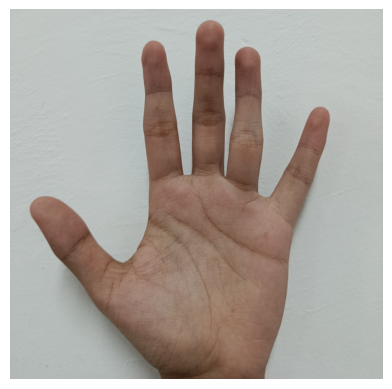

In [16]:
img_awal = plt.imread('Assets/tangan.jpeg')
plt.imshow(img_awal)
plt.axis('off')

# Tahap Awal

Blok kode ini mengorkestrasi seluruh tahapan pra-pemrosesan citra secara berurutan. Proses dimulai dengan memuat gambar langsung ke dalam representasi grayscale, meresolusi ulang dimensinya menjadi $256\times256$ piksel, dan mengekstraksi garis kontur objek menggunakan operator deteksi tepi Prewitt. Hasil ekstraksi tersebut kemudian dikonversi secara tegas menjadi citra biner (hitam-putih) menggunakan nilai ambang batas (threshold) 20. Terakhir, keempat fase transformasi gambar ini dari citra awal hingga citra biner divisualisasikan secara berdampingan pada satu kanvas terpadu menggunakan tata letak subplot Matplotlib guna mempermudah analisis komparatif tahap demi tahap.

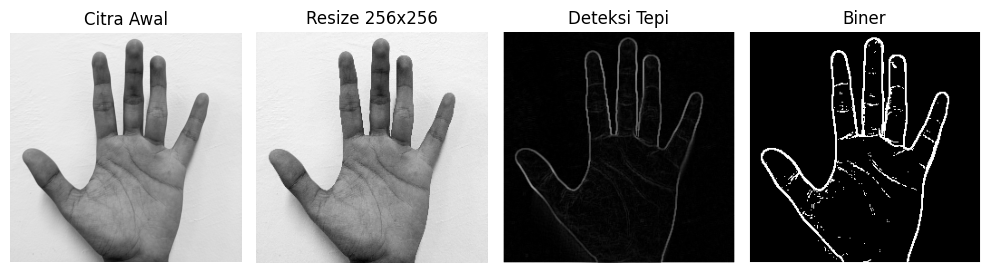

In [17]:
img_awal = cv2.imread('Assets/tangan.jpeg', cv2.IMREAD_GRAYSCALE)
citra_resized = fungsi_dua(img_awal, new_width=256, new_height=256)
citra_tepi_prewitt = edge_detection(citra_resized, prewittx, prewitty)
citra_biner = fungsi_satu(citra_tepi_prewitt, batas=20)

plt.figure(figsize=(10, 10))

plt.subplot(1, 4, 1)
plt.imshow(img_awal, cmap='gray')
plt.title("Citra Awal")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(citra_resized, cmap='gray')
plt.title("Resize 256x256")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(citra_tepi_prewitt, cmap='gray')
plt.title("Deteksi Tepi")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(citra_biner, cmap='gray')
plt.title("Biner")
plt.axis('off')

plt.tight_layout()
plt.show()

# Operasi matriks kernel berukuran 3x3

Blok kode ini mengeksekusi secara komprehensif seluruh rangkaian operasi morfologi citra menggunakan matriks kernel berukuran 3x3 berisikan nilai 1. Prosesnya mencakup eksekusi operasi dasar yakni dilasi dan erosi , operasi kombinasi tingkat lanjut berupa opening (erosi dilanjutkan dilasi) dan closing (dilasi dilanjutkan erosi) , serta manipulasi struktur kerangka objek melalui algoritma thinning dan thickening. Kode ini juga menghitung gradient morph  dengan mengekstraksi selisih antara hasil dilasi dan erosi guna menonjolkan batas luar tepi objek. Pada tahap akhir, seluruh luaran dari ketujuh proses modifikasi tersebut dirender secara serentak ke dalam sebuah kanvas grid berukuran 2x4 menggunakan tata letak Matplotlib agar perbedaan karakteristik dari masing-masing metode dapat dianalisis secara komparatif.

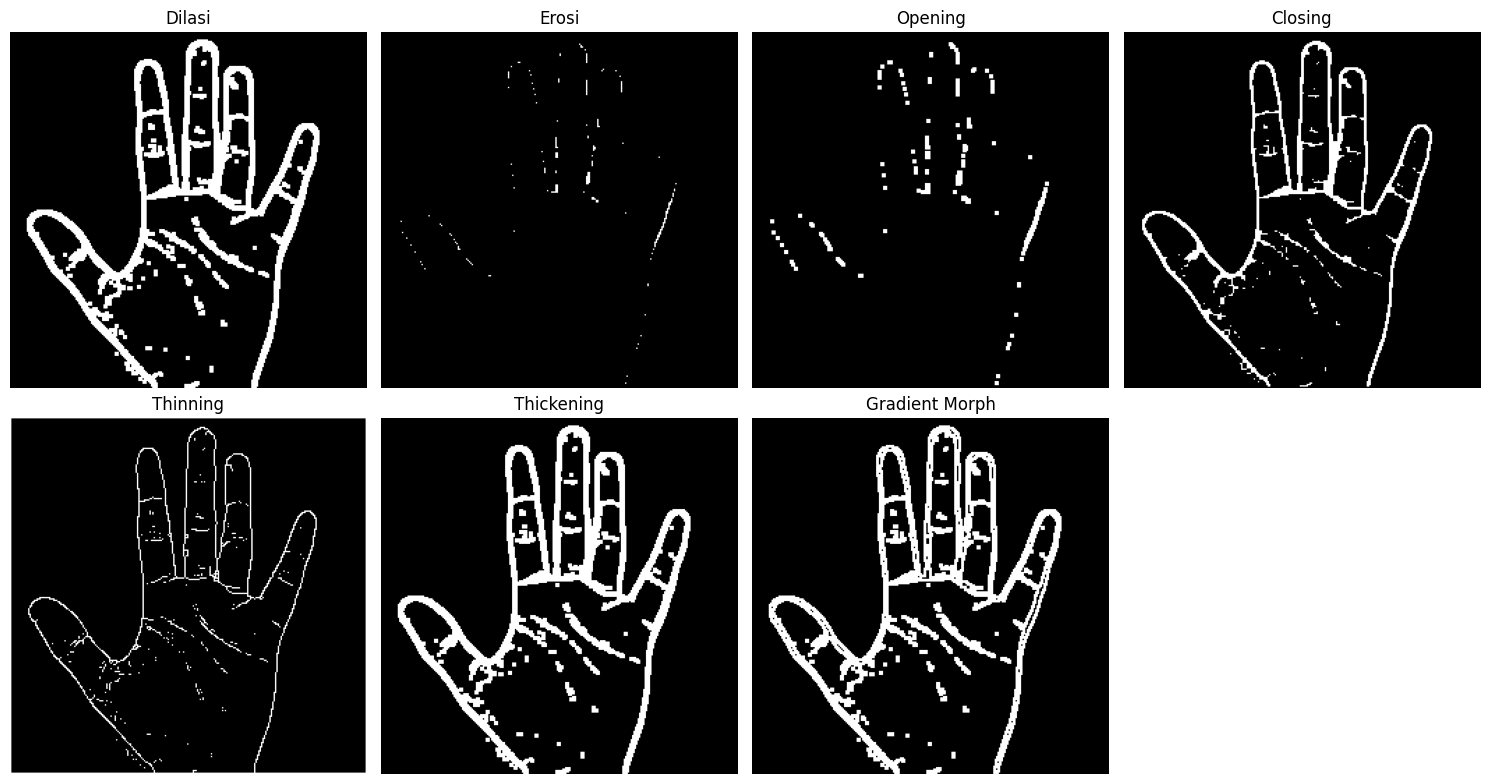

In [18]:
kernel33 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

hasil_dilasi = metode_satu(citra_biner, kernel33)
hasil_erosi = metode_dua(citra_biner, kernel33)

langkah_erosi = metode_dua(citra_biner, kernel33)
hasil_opening = metode_satu(langkah_erosi, kernel33)

langkah_dilasi = metode_satu(citra_biner, kernel33)
hasil_closing = metode_dua(langkah_dilasi, kernel33)

hasil_thinning = metode_tiga(citra_biner)
hasil_thickening = metode_empat(citra_biner, kernel33, iterasi=1)

hasil_gradient = hasil_dilasi - hasil_erosi

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(hasil_dilasi, cmap='gray')
plt.title("Dilasi")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(hasil_erosi, cmap='gray')
plt.title("Erosi")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(hasil_opening, cmap='gray')
plt.title("Opening")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(hasil_closing, cmap='gray')
plt.title("Closing")
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(hasil_thinning, cmap='gray')
plt.title("Thinning")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(hasil_thickening, cmap='gray')
plt.title("Thickening")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(hasil_gradient, cmap='gray')
plt.title("Gradient Morph")
plt.axis('off')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi yang dihasilkan menggunakan matriks kernel 3x3, setiap operasi morfologi memberikan perubahan struktural yang moderat namun jelas pada garis kontur telapak tangan. Operasi Dilasi dengan kernel ini menebalkan piksel putih secukupnya untuk menutup celah kecil, sementara Erosi mengikis batas objek hingga beberapa garis terputus menjadi titik-titik samar. Kombinasi Opening terbukti efektif menghilangkan noise halus di luar objek, sedangkan Closing berhasil menambal lubang kecil di dalam garis tanpa mendistorsi bentuk asli secara berlebihan. Pada manipulasi kerangka, Thinning mereduksi ketebalan menjadi kerangka satu piksel, dan Thickening mempertebal batas secara selektif. Terakhir, Gradient Morph menonjolkan batas terluar citra secara presisi. Secara keseluruhan, penggunaan ukuran kernel 3x3 ini masih mempertahankan banyak detail asli citra.

# Operasi matriks kernel berukuran 5x5

Blok kode ini mereplikasi seluruh rangkaian operasi morfologi sebelumnya, namun secara spesifik meningkatkan area sapuan dengan mendefinisikan dan menerapkan matriks kernel berukuran 5x5 yang seluruh elemennya bernilai 1. Peningkatan dimensi kernel ini dieksekusi secara berulang untuk operasi dilasi, erosi, opening, closing, thickening, hingga ekstraksi gradient morph (sementara fungsi thinning tetap berjalan mandiri tanpa parameter kernel). Secara teknis, penggunaan matriks 5x5 yang memindai area seluas 25 piksel sekaligus ini dirancang untuk menghasilkan efek transformasi yang jauh lebih agresif dibandingkan kernel 3x3; di mana tingkat penebalan objek akan menjadi lebih masif, pengikisan batas tepi akan jauh lebih destruktif, dan reduksi noise akan memengaruhi detail struktur sitra dalam skala yang lebih luas.

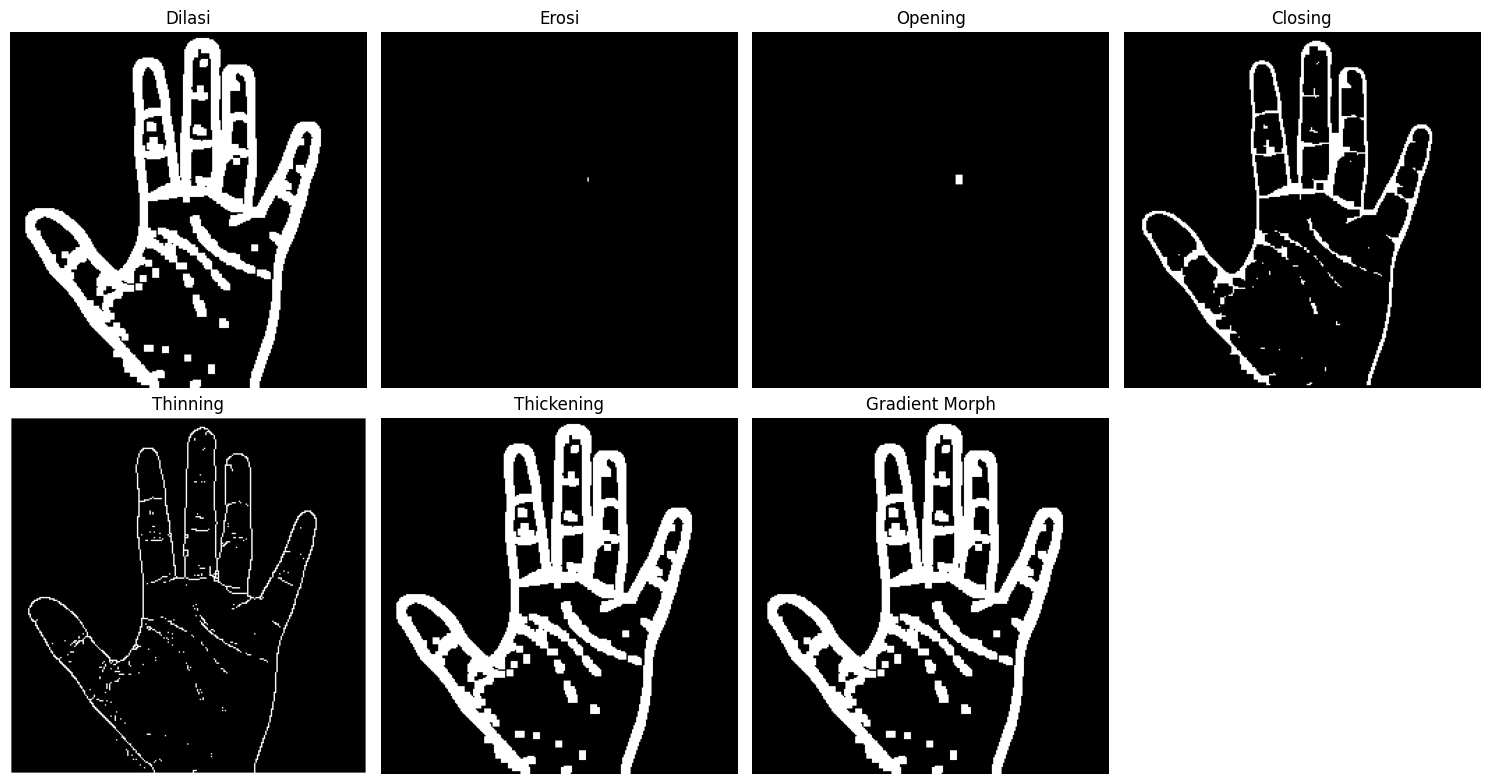

In [19]:
kernel55 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.uint8)

hasil_dilasi2 = metode_satu(citra_biner, kernel55)
hasil_erosi2 = metode_dua(citra_biner, kernel55)

langkah_erosi2 = metode_dua(citra_biner, kernel55)
hasil_opening2 = metode_satu(langkah_erosi2, kernel55)

langkah_dilasi2 = metode_satu(citra_biner, kernel55)
hasil_closing2 = metode_dua(langkah_dilasi2, kernel55)

hasil_thinning2 = metode_tiga(citra_biner)
hasil_thickening2 = metode_empat(citra_biner, kernel55, iterasi=1)

hasil_gradient2 = hasil_dilasi2 - hasil_erosi2

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(hasil_dilasi2, cmap='gray')
plt.title("Dilasi")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(hasil_erosi2, cmap='gray')
plt.title("Erosi")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(hasil_opening2, cmap='gray')
plt.title("Opening")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(hasil_closing2, cmap='gray')
plt.title("Closing")
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(hasil_thinning2, cmap='gray')
plt.title("Thinning")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(hasil_thickening2, cmap='gray')
plt.title("Thickening")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(hasil_gradient2, cmap='gray')
plt.title("Gradient Morph")
plt.axis('off')

plt.tight_layout()
plt.show()

Penggunaan matriks kernel $5\times5$ menghasilkan transformasi struktural yang jauh lebih ekstrem dan destruktif dibandingkan kernel $3\times3$. Pada operasi Dilasi, Closing, dan Thickening, objek mengalami penebalan masif yang menyebabkan hilangnya celah detail antar garis sehingga bentuk asli kontur tangan cenderung menyatu secara berlebihan. Sebaliknya, sapuan matriks $5\times5$ pada operasi Erosi dan Opening terbukti terlalu agresif menggerus piksel putih, sehingga hampir seluruh struktur tangan terhapus total menyisakan kanvas hitam pekat karena ketebalan asli garis lebih kecil dari dimensi matriks kernel. Sementara itu, Gradient Morph menampilkan outline yang sangat tebal sebagai akibat dari besarnya selisih antara hasil dilasi ekstrem dan erosi yang nyaris hilang. Secara keseluruhan, pembesaran ukuran kernel ini sangat drastis dalam mereduksi noise, namun secara bersamaan mengorbankan integritas detail dan merusak bentuk asli citra.

# Kombinasi 2 proses morfologi

Blok kode ini mengeksekusi dan memvisualisasikan kombinasi dua operasi morfologi secara berurutan menggunakan matriks kernel berukuran 3x3. Terdapat empat variasi alur pemrosesan yang diimplementasikan dengan menggabungkan fungsi dasar secara sekuensial: Opening + Closing (menghilangkan noise eksternal terlebih dahulu, lalu menambal celah internal), Closing + Opening (menambal struktur objek terlebih dahulu, disusul reduksi noise), Opening + Dilasi (membersihkan titik-titik artefak lalu menebalkan struktur utama yang tersisa), serta Closing + Erosi (menambal lubang pada objek lalu menipiskan batas terluarnya secara keseluruhan). Keempat hasil modifikasi tingkat lanjut ini kemudian dirender ke dalam kanvas grid berukuran 2x2 menggunakan Matplotlib untuk memudahkan analisis perbandingan efektivitas setiap urutan kombinasi.

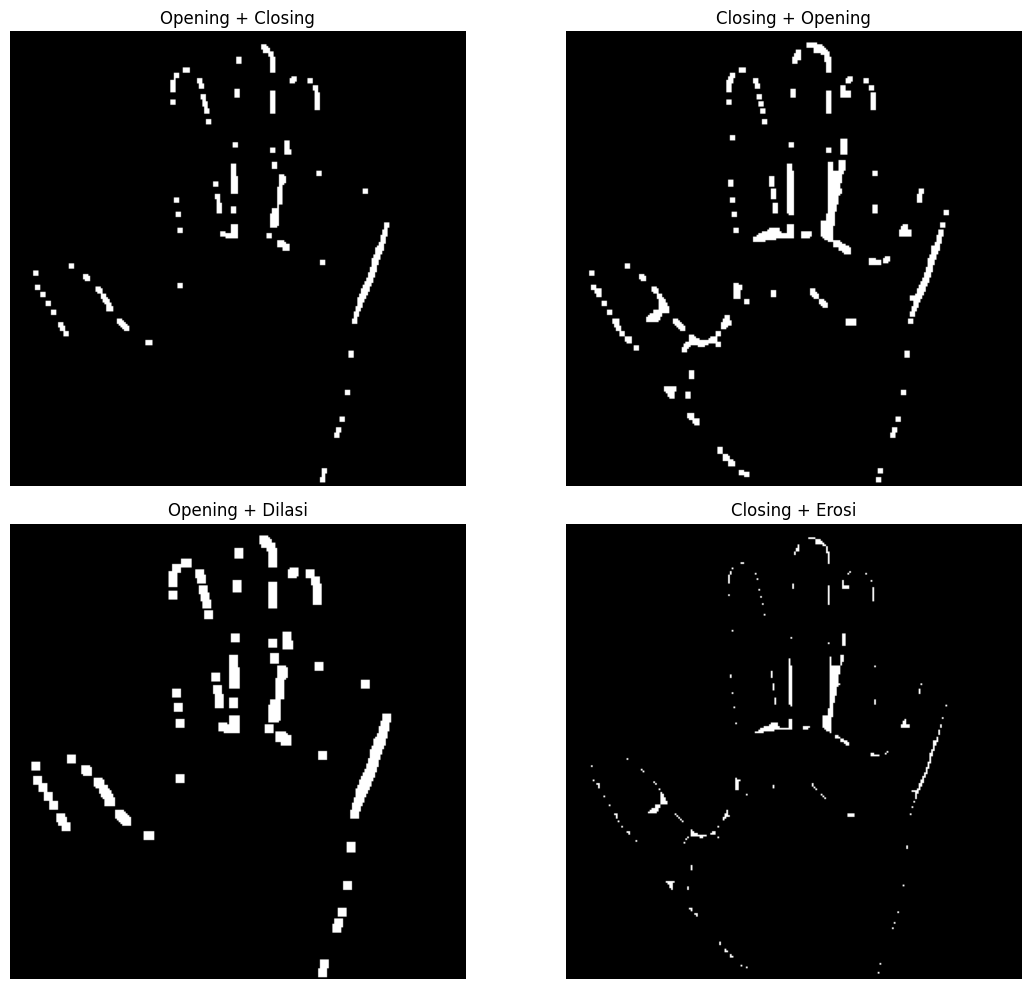

In [20]:
langkah1_erosi = metode_dua(citra_biner, kernel33)
hasil_opening1 = metode_satu(langkah1_erosi, kernel33)
langkah1_dilasi = metode_satu(hasil_opening1, kernel33)
kombinasi_1 = metode_dua(langkah1_dilasi, kernel33)

langkah2_dilasi = metode_satu(citra_biner, kernel33)
hasil_closing2 = metode_dua(langkah2_dilasi, kernel33)
langkah2_erosi = metode_dua(hasil_closing2, kernel33)
kombinasi_2 = metode_satu(langkah2_erosi, kernel33)

langkah3_erosi = metode_dua(citra_biner, kernel33)
hasil_opening3 = metode_satu(langkah3_erosi, kernel33)
kombinasi_3 = metode_satu(hasil_opening3, kernel33)

langkah4_dilasi = metode_satu(citra_biner, kernel33)
hasil_closing4 = metode_dua(langkah4_dilasi, kernel33)
kombinasi_4 = metode_dua(hasil_closing4, kernel33)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(kombinasi_1, cmap='gray')
plt.title("Opening + Closing")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(kombinasi_2, cmap='gray')
plt.title("Closing + Opening")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(kombinasi_3, cmap='gray')
plt.title("Opening + Dilasi")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(kombinasi_4, cmap='gray')
plt.title("Closing + Erosi")
plt.axis('off')

plt.tight_layout()
plt.show()

Kombinasi operasi morfologi terbukti lebih efektif dalam menyeimbangkan reduksi noise dan pelestarian bentuk dibandingkan operasi tunggal. Urutan Closing + Opening menghasilkan batas objek yang paling optimal karena berhasil menambal celah terlebih dahulu sebelum menghapus noise eksternal, sehingga struktur garis kontur tangan lebih terhubung dibandingkan Opening + Closing yang telanjur memutus konektivitas garis saat pengikisan awal. Sementara itu, Opening + Dilasi secara agresif membersihkan noise lalu mempertebal sisa piksel secara masif, menghasilkan bentuk objek berupa segmen garis tebal yang mencolok namun terputus-putus. Sebaliknya, kombinasi Closing + Erosi berhasil mempertahankan konektivitas kerangka awal, namun proses pengikisan di tahap akhir membuat seluruh ketebalan garis menjadi sangat tipis, redup, dan kurang tegas dibandingkan citra aslinya.

# Eksplorasi mandiri

Blok kode ini merupakan tahap eksplorasi mandiri yang dirancang untuk mengekstraksi dan memodifikasi garis kontur telapak tangan agar menghasilkan efek outline ganda yang unik. Prosesnya diawali dengan mengubah ukuran citra menjadi $500\times500$ piksel dan menerapkan thresholding pada nilai ambang 127 untuk memisahkan objek secara tegas dari latar belakang. Setelah batas tepi utama diekstraksi menggunakan operasi Gradient Morph (selisih antara hasil dilasi dan erosi), kode ini melakukan trik manipulasi lanjutan dengan mendilasi garis tepi tersebut dan menguranginya kembali dengan garis tepi asalnya. Hasil akhirnya berupa visualisasi garis tepi luar baru yang berongga, yang kemudian dirender ke layar beserta garis sumbu koordinatnya (plt.axis('on')) untuk mempermudah analisis dimensi ukuran.

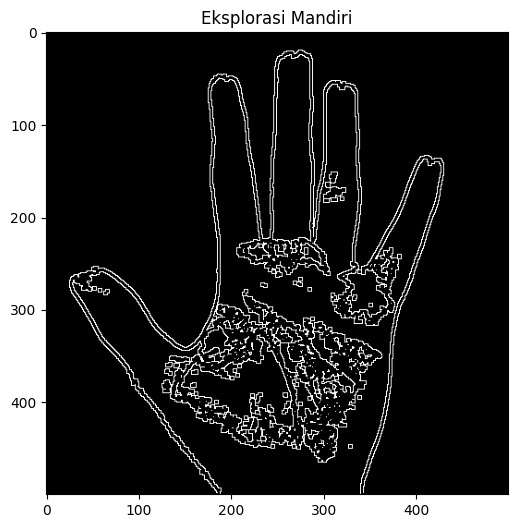

In [21]:
img_tangan = cv2.imread('Assets/tangan.jpeg', cv2.IMREAD_GRAYSCALE)
tangan_resized = fungsi_dua(img_tangan, new_width=500, new_height=500)

tangan_biner = fungsi_satu(tangan_resized, batas=127)

tangan_dilasi = metode_satu(tangan_biner, kernel33)
tangan_erosi = metode_dua(tangan_biner, kernel33)
gradient_morph = np.clip(tangan_dilasi.astype(int) - tangan_erosi.astype(int), 0, 255).astype(np.uint8)

dilasi_outline = metode_satu(gradient_morph, kernel33)
outline_ganda = np.clip(dilasi_outline.astype(int) - gradient_morph.astype(int), 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(outline_ganda, cmap='gray')
plt.title("Eksplorasi Mandiri")
plt.axis('on')
plt.show()

In [ ]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    return canvas

In [ ]:
def edge_detection(img, kernelx, kernely):
    
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.abs(gx) + np.abs(gy)
    
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [ ]:
resized_tangan = fungsi_dua(img_tangan, new_width=500, new_height=500)
median = filter_citra(resized_tangan, 3, 'median')
tepi_pr = edge_detection(median, prewittx, prewitty)
th = fungsi_satu(tepi_pr, 30)
thick = metode_empat(th, kernel33, iterasi=2)
tepi_pr1 = edge_detection(thick, prewittx, prewitty)

plt.imshow(tepi_pr1, cmap='gray')
plt.title('Eksplorasi Mandiri')
plt.axis('off')

Pada tahap eksplorasi mandiri, resize dan thresholding digunakan di awal untuk menstandarisasi resolusi citra  piksel dan memisahkan objek telapak tangan dari latar belakang menjadi bentuk biner yang solid. Selanjutnya, operasi Gradient Morph (selisih antara hasil dilasi dan erosi) diaplikasikan dengan tujuan mengekstrak batas tepi (outline) tunggal dari objek tersebut. Untuk menciptakan hasil akhir yang unik, garis tepi tunggal ini kemudian didilasi kembali agar menebal, lalu dikurangi dengan matriks garis tepi aslinya. Modifikasi matematis ini secara efektif mengosongkan piksel di bagian tengah dari garis yang telah menebal, sehingga pengaruhnya pada citra akhir menghasilkan efek visual berupa kontur garis ganda (hollow/double outline) yang tajam, berongga, dan memperjelas tekstur kerutan di dalam telapak tangan.

# Kesimpulan

Secara keseluruhan, pengerjaan Modul 4 ini sangat relevan dengan pemenuhan Capaian Pembelajaran Mata Kuliah (CPMK) Pengolahan Citra Digital, khususnya dalam hal pemahaman algoritma spasial dan analisis ekstraksi fitur. Berikut adalah benang merah antara hasil praktikum dan ketercapaian CPMK:
1. Penguasaan Implementasi Algoritma Spasial DasarMelalui modul ini, kamu tidak hanya menggunakan fungsi instan, tetapi terbukti mampu menerjemahkan logika matematika dari operasi morfologi dasar (Dilasi dan Erosi) ke dalam blok kode iteratif. Pemahaman mendalam mengenai bagaimana matriks kernel memindai dan memanipulasi piksel biner ini membuktikan ketercapaian capaian pembelajaran terkait penguasaan algoritma pemrosesan spasial tingkat rendah.
2. Kemampuan Evaluasi dan Analisis KritisEksplorasi perbandingan ukuran kernel ($3\times3$ vs $5\times5$) serta kombinasi operasi tingkat lanjut (Opening dan Closing) melatih kemampuan analitis. Kamu berhasil memenuhi tuntutan dosen pengampu agar mahasiswa mampu mengevaluasi secara kritis pengaruh modifikasi parameter terhadap tingkat reduksi noise, penebalan objek, serta risiko destruksi struktur asli citra.
3. Sintesis dan Pemecahan Masalah (Problem Solving)Pada tahap eksplorasi mandiri, penciptaan algoritma kontur ganda (double outline) menunjukkan kemampuan pemecahan masalah yang kreatif. Kamu terbukti mampu memodifikasi, membalikkan logika, dan merangkai operasi gradient morph dengan dilasi secara berurutan. Ini sejalan dengan target capaian tertinggi mata kuliah, di mana mahasiswa dituntut siap mengimplementasikan teknik ekstraksi fitur (feature extraction) yang andal untuk kebutuhan sistem Computer Vision yang lebih kompleks di dunia nyata.